# Temporal and genre analysis for dialogue density

With this notebook, I'm analysing how dialogue density has shifted across decades (1980s–2020s) and whether those shifts differ by genre. It reads from `thesis-outputs/pacing_dialogue.json` (produced by `pacing-dialogue-density.ipynb`) and joins it with year and genre from `analysis_corpus_final.json`.

**A note on pacing.** Pacing (words per scene) was computed for 1,592 of 1,627 scripts (but reliable scene counts, defined as ≥10 detected scene headings) exist for only 510 scripts (31%). Worse, the surviving fraction is not uniform across decades: 39% of 1980s scripts pass the threshold vs 12% of 2010s scripts. Any decade trend in pacing would therefore reflect parser reliability differences across eras, not actual structural change in the films. Pacing is retained in `pacing_dialogue.json` as a per-script field for case-study use, but I exclude it from the corpus-level analysis here.

**Structure:**
1. Load and merge data
2. Decade trends for full corpus
3. Genre trends for 8 major genres over time
4. Summary statistics table

## 1. Load and merge

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
from collections import defaultdict

LOCAL_ROOT    = Path('/Users/derinsavasan/Desktop/parsons-spring/thesis')
PACING_PATH   = LOCAL_ROOT / 'docs/thesis-outputs/pacing_dialogue.json'
METADATA_PATH = LOCAL_ROOT / 'Movie-Script-Database/scripts/metadata/analysis_corpus_final.json'

# Match case-studies notebook typography
plt.rcParams['font.family'] = 'Baskerville'
plt.rcParams['font.size']   = 11

pacing_data = {r['slug']: r for r in json.loads(PACING_PATH.read_text())}
corpus      = json.loads(METADATA_PATH.read_text())

records = []
for entry in corpus:
    slug   = entry['slug']
    year   = entry.get('year')
    genres = entry.get('tmdb', {}).get('genres', [])
    p      = pacing_data.get(slug)
    if not p or not year:
        continue
    records.append({
        'slug':             slug,
        'year':             year,
        'decade':           (year // 10) * 10,
        'genres':           genres,
        'dialogue_density': p['dialogue_density'],
    })

print(f'Total merged records  : {len(records)}')
print(f'Dialogue density (all): {len(records)}')

Total merged records  : 1627
Dialogue density (all): 1627


## 2. Decade trends for full corpus

Median dialogue density per decade with interquartile range (25th–75th percentile) as a band. All 1,627 scripts are included.

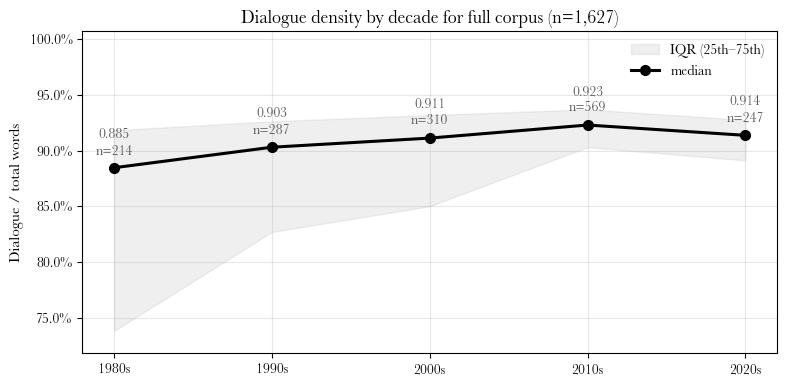

Decade     Median       Q1       Q3      n
--------------------------------------------
1980s       0.885    0.738    0.918    214
1990s       0.903    0.827    0.926    287
2000s       0.911    0.850    0.932    310
2010s       0.923    0.903    0.937    569
2020s       0.914    0.891    0.928    247


In [2]:
DECADES       = [1980, 1990, 2000, 2010, 2020]
DECADE_LABELS = ['1980s', '1990s', '2000s', '2010s', '2020s']
x = np.arange(len(DECADES))


def decade_stats(recs, field):
    medians, q1s, q3s, ns = [], [], [], []
    for d in DECADES:
        vals = [r[field] for r in recs if r['decade'] == d and r[field] is not None]
        if vals:
            medians.append(np.median(vals))
            q1s.append(np.percentile(vals, 25))
            q3s.append(np.percentile(vals, 75))
            ns.append(len(vals))
        else:
            medians.append(np.nan)
            q1s.append(np.nan)
            q3s.append(np.nan)
            ns.append(0)
    return np.array(medians), np.array(q1s), np.array(q3s), ns


d_med, d_q1, d_q3, d_ns = decade_stats(records, 'dialogue_density')

fig, ax = plt.subplots(figsize=(8, 4))

ax.fill_between(x, d_q1, d_q3, alpha=0.15, color='#999999', label='IQR (25th–75th)')
ax.plot(x, d_med, marker='o', color='black', lw=2.2, markersize=7, label='median')

for i, (m, n) in enumerate(zip(d_med, d_ns)):
    ax.annotate(f'{m:.3f}\nn={n}', (x[i], m), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=10, color='#555')

ax.set_xticks(x)
ax.set_xticklabels(DECADE_LABELS, fontsize=11)
ax.set_title('Dialogue density by decade for full corpus (n=1,627)', fontsize=13, fontweight='bold')
ax.set_ylabel('Dialogue / total words', fontsize=11)
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=1))
ax.tick_params(labelsize=10)

pad = 0.02
ax.set_ylim(d_q1.min() - pad, d_q3.max() + pad + 0.05)

ax.legend(frameon=False, fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(LOCAL_ROOT / 'docs/thesis-outputs/decade_trends.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'{"Decade":<8} {"Median":>8} {"Q1":>8} {"Q3":>8} {"n":>6}')
print('-' * 44)
for i, lbl in enumerate(DECADE_LABELS):
    print(f'{lbl:<8} {d_med[i]:>8.3f} {d_q1[i]:>8.3f} {d_q3[i]:>8.3f} {d_ns[i]:>6}')

## 3. Genre trends with small multiples

One panel per genre (2×4 grid). Each panel shows the median dialogue density per decade as a line with the IQR band, zoomed to that genre's actual data range. The dashed gray line is the full-corpus median for reference. This makes within-genre trends and cross-genre differences readable in a way a single crowded panel cannot.

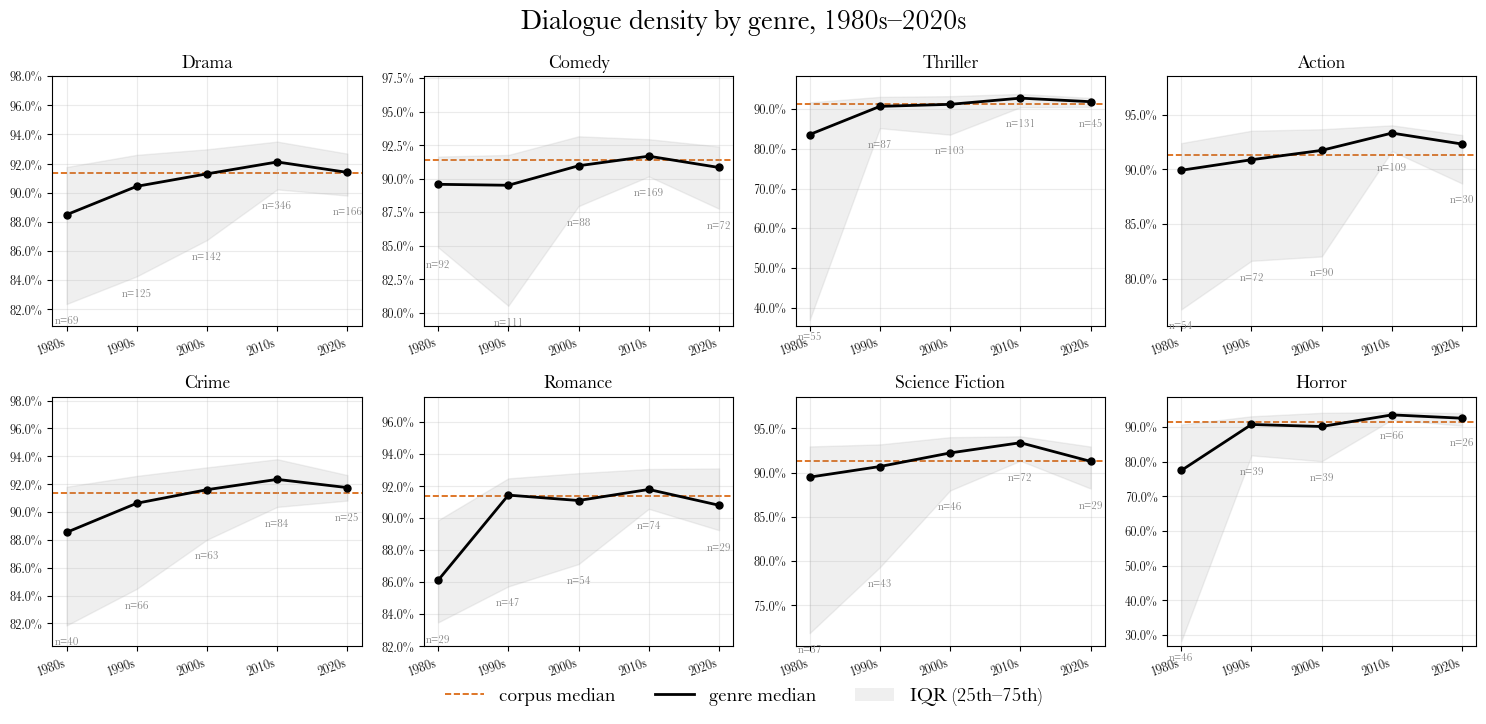

In [3]:
GENRES = ['Drama', 'Comedy', 'Thriller', 'Action', 'Crime', 'Romance', 'Science Fiction', 'Horror']
MIN_N  = 8

corpus_density_med = float(np.nanmedian([r['dialogue_density'] for r in records]))


def genre_decade_stats(genre):
    medians, q1s, q3s, ns = [], [], [], []
    for d in DECADES:
        vals = [
            r['dialogue_density'] for r in records
            if r['decade'] == d and genre in r['genres']
        ]
        if len(vals) >= MIN_N:
            medians.append(np.median(vals))
            q1s.append(np.percentile(vals, 25))
            q3s.append(np.percentile(vals, 75))
        else:
            medians.append(np.nan)
            q1s.append(np.nan)
            q3s.append(np.nan)
        ns.append(len(vals))
    return np.array(medians), np.array(q1s), np.array(q3s), ns


fig, axes = plt.subplots(2, 4, figsize=(15, 7), sharey=False)
axes = axes.flatten()

for ax, genre in zip(axes, GENRES):
    med, q1, q3, ns = genre_decade_stats(genre)
    mask = ~np.isnan(med)

    # Corpus median reference
    ax.axhline(corpus_density_med, color='#D95F02', lw=1.2, linestyle='--', zorder=1)

    # IQR band
    if mask.sum() >= 2:
        ax.fill_between(x[mask], q1[mask], q3[mask], alpha=0.15, color='#999999')

    # Median line
    ax.plot(x[mask], med[mask], marker='o', color='black', lw=2, markersize=5, zorder=3)

    # n annotations
    for i in range(len(DECADES)):
        if not np.isnan(med[i]):
            ax.annotate(f'n={ns[i]}', (x[i], q1[i]),
                        textcoords='offset points', xytext=(0, -14),
                        ha='center', fontsize=8, color='gray')

    ax.set_title(genre, fontsize=13, fontweight='bold', color='black')
    ax.set_xticks(x)
    ax.set_xticklabels(DECADE_LABELS, fontsize=9, rotation=20, ha='right')
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=1))
    ax.tick_params(labelsize=9)
    ax.grid(True, alpha=0.25)

    valid_q1 = q1[mask]
    valid_q3 = q3[mask]
    if len(valid_q1):
        pad = 0.015
        ax.set_ylim(min(valid_q1.min(), corpus_density_med) - pad,
                    max(valid_q3.max(), corpus_density_med) + pad + 0.03)

handles = [
    plt.Line2D([0], [0], color='#D95F02', lw=1.2, linestyle='--', label='corpus median'),
    plt.Line2D([0], [0], color='black', lw=2, label='genre median'),
    plt.Rectangle((0, 0), 1, 1, fc='#999999', alpha=0.15, label='IQR (25th–75th)'),
]
fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False,
           fontsize=14, bbox_to_anchor=(0.5, -0.04))

plt.suptitle('Dialogue density by genre, 1980s–2020s', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig(LOCAL_ROOT / 'docs/thesis-outputs/genre_trends.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Summary statistics table

Median dialogue density per genre per decade with sample sizes. Asterisked cells have n < 8 and are suppressed in the plot above.

In [4]:
print('DIALOGUE DENSITY via median proportion (n in parentheses)')
header = f'{"Genre":<18}' + ''.join(f'{lbl:>14}' for lbl in DECADE_LABELS)
print(header)
print('-' * (18 + 14 * len(DECADES)))

for genre in GENRES:
    row = f'{genre:<18}'
    for d in DECADES:
        vals = [
            r['dialogue_density'] for r in records
            if r['decade'] == d and genre in r['genres']
        ]
        if len(vals) >= MIN_N:
            row += f'{np.median(vals):>8.3f} ({len(vals):>3})'
        elif vals:
            row += f'{"—":>8}  ({len(vals):>2}*)'
        else:
            row += f'{"—":>14}'
    print(row)

print()

# Full-corpus row
row = f'{"ALL (corpus)":<18}'
for d in DECADES:
    vals = [r['dialogue_density'] for r in records if r['decade'] == d]
    row += f'{np.median(vals):>8.3f} ({len(vals):>3})'
print(row)

print()
print('* suppressed in plot (n < 8); shown here for completeness')

DIALOGUE DENSITY via median proportion (n in parentheses)
Genre                      1980s         1990s         2000s         2010s         2020s
----------------------------------------------------------------------------------------
Drama                0.885 ( 69)   0.904 (125)   0.913 (142)   0.921 (346)   0.914 (166)
Comedy               0.896 ( 92)   0.895 (111)   0.910 ( 88)   0.917 (169)   0.908 ( 72)
Thriller             0.836 ( 55)   0.907 ( 87)   0.912 (103)   0.928 (131)   0.919 ( 45)
Action               0.899 ( 54)   0.909 ( 72)   0.917 ( 90)   0.933 (109)   0.923 ( 30)
Crime                0.885 ( 40)   0.906 ( 66)   0.916 ( 63)   0.923 ( 84)   0.917 ( 25)
Romance              0.861 ( 29)   0.914 ( 47)   0.911 ( 54)   0.918 ( 74)   0.908 ( 29)
Science Fiction      0.895 ( 37)   0.907 ( 43)   0.922 ( 46)   0.934 ( 72)   0.913 ( 29)
Horror               0.774 ( 46)   0.907 ( 39)   0.901 ( 39)   0.934 ( 66)   0.925 ( 26)

ALL (corpus)         0.885 (214)   0.903 (287)   0.